In [1]:
## Libraries, modules
import os
import pandas as pd
import soundfile as sf
import matplotlib.pyplot as plt
import numpy as np
import scipy.signal as signal
import cv2
from skimage.feature import peak_local_max

## Recording file
rec_filename = "000_1.392_seq.flac" # 001_235.717_seq.flac 271_48196.251_seq.flac

## FFT Parameters
win_type = "Taylor"
win_size = 2000  # Window size, 1000 to 4000 are ideal
overlap = 75 # Overlap %

# Determine other parameters and initialize FFT
fs = 48000  # Your sampling frequency
hop_size = int(win_size*(1-overlap/100)) # Step/hop size
FFT_sample_T = win_size/fs*(1-overlap/100) # FFT samples duration in s (this is not actual resolution)
if (win_type == "Hann"):
    win = signal.windows.hann(win_size) # Hann window
elif (win_type == "Taylor"):
    win = signal.windows.taylor(win_size, nbar=3, sll=25, norm=True) # Taylor window with parameters: nbar (2), sidelobe suppression level (-25)
elif (win_type == "Rect"):
    win = signal.windows.boxcar(win_size) # Rectangular window
elif (win_type == "Hamming"):
    win = signal.windows.hamming(win_size) # Rectangular window
SFT = signal.ShortTimeFFT(win, hop=hop_size, fs=fs) # Initialize ShortTimeFFT

In [2]:
## Functions
# Spectrogram bandpass filter
def spec_bandpass(spec, f_max, f_bins, f_low, f_high):
    f_bl = int(f_low/f_max*f_bins) # Low frequency bin
    f_bh = int(f_high/f_max*f_bins) # High frequency bin
    return spec[f_bl:f_bh,:]

# Measure time and frequency of detected signals (after correlation and local maxima search)
def meas_time_freq(t_min, t_max, t_bins, local_maxima):
    times = np.linspace(t_min, t_max, t_bins)[local_maxima[:, 1]]  # Time values from indices
    freqs = np.linspace(f_min, f_max, f_bins)[local_maxima[:, 0]]  # Frequency values from indices
    return times, freqs

# Add detected signals to list
def signals2list(signal_type, signals_detected, detected_times, detected_freqs, corr_values):
    for i in range(len(detected_times)):
        signals_detected.append([
            signal_type,  # Signal type
            round(detected_times[i], 2),  # Time rounded to 2 decimal places
            int(detected_freqs[i]),  # Frequency as an integer
            round(corr_values[i], 2)  # Correlation value rounded to 2 decimal places
        ])
    return signals_detected

# Blank the spectrogram based on local maxima
def blank_spectrogram(blanked_spectrogram, local_maxima, t_start_corr, t_end_corr, signal, t_bins, FFT_sample_T):
    for local_max in local_maxima:
        signal_time_width = signal.shape[1] # Calculate signal width (time samples)
        t_idx = local_max[1]  # Time index where signal starts (lower left corner)
        t_start_idx = max(0, t_idx - int(t_start_corr/FFT_sample_T)) # Start time index
        t_end_idx = min(t_bins, t_idx + signal_time_width + int(t_end_corr/FFT_sample_T)) # End time index
        blanked_spectrogram[:, t_start_idx:t_end_idx] = np.min(recording_crop) # Blank spectrogram in signal time window
    return blanked_spectrogram

# Remove short detections (noise when detecting tone signals)
def remove_short_detections(arr, min_ones):
    result = arr.copy()
    i = 0
    while i < len(result):
        if result[i] == 1:  # Found the start of a sequence of 1s
            start = i
            while i < len(result) and result[i] == 1:  # Find the end of this sequence
                i += 1
            end = i
            if end - start < min_ones:  # If the length of the sequence is shorter than min_ones, set to 0
                for j in range(start, end):
                    result[j] = 0
        else:
            i += 1    
    return result

# Find tone signals based on timing
def find_tone_signals(bin_list, tones_freq_med):
    tone_signals = []
    start_idx = None
    for i, num in enumerate(bin_list):  # Go through detection array
        if num > 0:
            if start_idx is None:  # Beginning of a new sequence of 1s
                start_idx = i
        elif num == 0 and start_idx is not None:  # End the sequence when we hit a 0 after detecting 1s
            tone_signals.append((start_idx, i - 1, tones_freq_med[start_idx]))  # Add median value as third column
            start_idx = None    
    if start_idx is not None:  # If we end with a sequence of 1s and it's still open, close it
        tone_signals.append((start_idx, len(bin_list) - 1, tones_freq_med[start_idx]))  # Add median value as third column
    return tone_signals

# Monster function to translate tones
def translate_tones(tone_signals, FFT_sample_T):
    tones_list = [] # List with final output
    i = 0 # Initialize row index
    while i < len(tone_signals):
        duration_samples = tone_signals[i][1] - tone_signals[i][0] # Duration of each sequence, in samples
        row = [tone_signals[i][0], tone_signals[i][1], duration_samples, "", ""] # Add empty 5th column for frequency
        if (duration_samples > int(2.88*1.1/FFT_sample_T)): # Tone A is usually ~2.88 s, so longer tones mean that A & B or A & C are too close to each other
            raise ValueError("Check for possible A+B or A+C.")
        elif (duration_samples > int(2.88*0.9/FFT_sample_T)): # Tone A is usually ~2.88 s, using 10% margin
            row[3] = "A"
            row[4] = tone_signals[i][2] # Frequency sample
        elif (duration_samples > int(1.77*1.1/FFT_sample_T)): # Tone B is usually ~1.77 s, so longer tones mean that B & C are too close to each other
            raise ValueError("Check for possible B+C.")
        elif (duration_samples > int(1.77*0.9/FFT_sample_T)): # Tone B is usually ~1.77 s, using 10% margin
            row[3] = "B"
            row[4] = tone_signals[i][2] # Frequency sample
        elif (duration_samples > int(0.70*0.9/FFT_sample_T)): # Tone C is made of two tones, the first is usually ~0.70 s, using 10% margin
            if i + 1 < len(tone_signals): # Check if there is a next row
                next_duration_samples = tone_signals[i + 1][1] - tone_signals[i + 1][0]
                if (next_duration_samples < int(0.38*1.25/FFT_sample_T)):  # The second tone is usually ~0.38 s, using 20% margin
                    tones_list.append([tone_signals[i][0], tone_signals[i + 1][1], (tone_signals[i + 1][1] - tone_signals[i][0]), "C", tone_signals[i][2]])  # Merge rows and add "C" label
                    i += 2 # Skip the next row as it was merged with the current one
                    continue # Skip current row because it's merged with the next row
                else:
                    raise ValueError("C tone only partially detected (missing 2nd half).")
            else:
                raise ValueError("C tone only partially detected (end of tone_signals).")
        else:
            raise ValueError("C tone only partially detected (missing 1st half).")
        
        tones_list.append(row)
        i += 1 # Move to the next row

    return tones_list

## Signal durations (s)
def sig_length(sig_code):
    match sig_code:
        case 'A':
            return 3.00
        case 'B':
            return 1.77
        case 'C':
            return 1.63
        case 'D':
            return 1.61
        case 'E':
            return 1.27
        case 'F':
            return 0.98
        case 'G':
            return 2.12
        case 'X':
            return 16.18

In [3]:
## Read full audio recording
audio_rec, fs = sf.read("./signal_sequences/"+rec_filename)
data = audio_rec[:,0] + audio_rec[:,0] # LSumming the two doesn't improve SNR, but doesn't hurt either.

## Initialize list of detected signals
signals_detected = []

In [4]:
## Generate Spectrogram (2D FFT)
Sx2 = SFT.spectrogram(data) # Compute the spectrogram (absolute square of STFT)
Sx2[Sx2 == 0] = np.min(Sx2[np.nonzero(Sx2)]) # Substitute zeros with the minimum non-zero value to avoid log(0)
Sx2_dB = 10 * np.log10(Sx2) # Convert spectrogram to dB
t_min, t_max, f_min, f_max = SFT.extent(len(audio_rec), center_bins=True) # Get frequency and time boundaries
f_bins, t_bins = Sx2.shape # Get the number of frequency and time bins

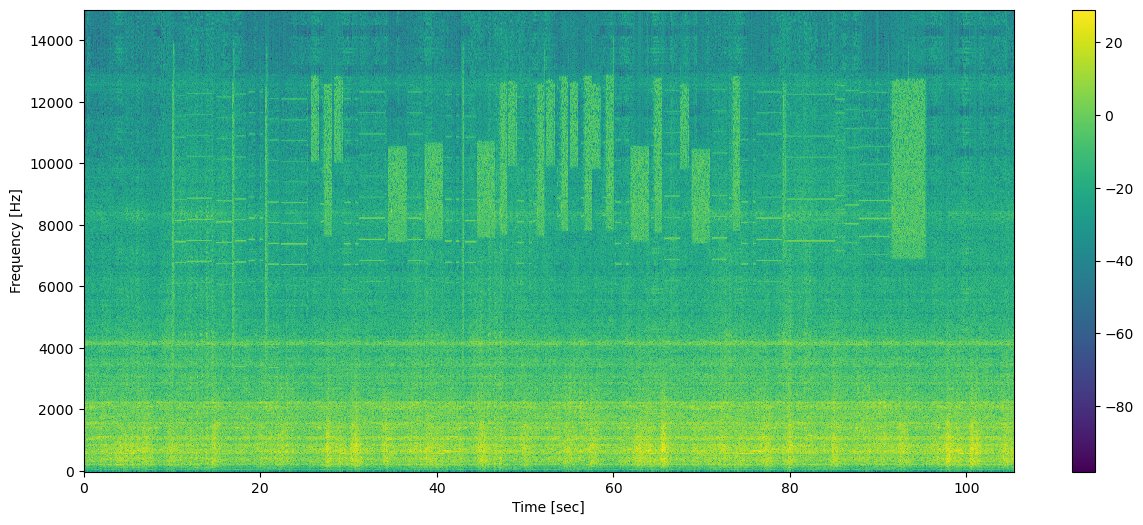

In [5]:
## Crop spectrogram to avoid high frequency aliased signals
# Frequency range
f_low = 0  # Hz
f_high = 15000  # Hz
f_0 = int(f_low * f_bins / (f_max - f_min))
f_1 = int(f_high * f_bins / (f_max - f_min))

# Time range
t_start = t_min
t_end = t_max
t_0 = np.searchsorted(np.linspace(t_min, t_max, t_bins), t_start)
t_1 = np.searchsorted(np.linspace(t_min, t_max, t_bins), t_end)

# Crop the spectrogram to the selected frequency and time ranges
recording_crop = Sx2_dB[f_0:f_1, t_0:t_1].astype(np.float32)

# Plot the modified spectrogram
plt.figure(figsize=(15,6))
plt.pcolormesh(np.linspace(t_min, t_max, t_bins)[t_0:t_1], np.linspace(f_min, f_max, f_bins)[f_0:f_1], recording_crop)
plt.colorbar()
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

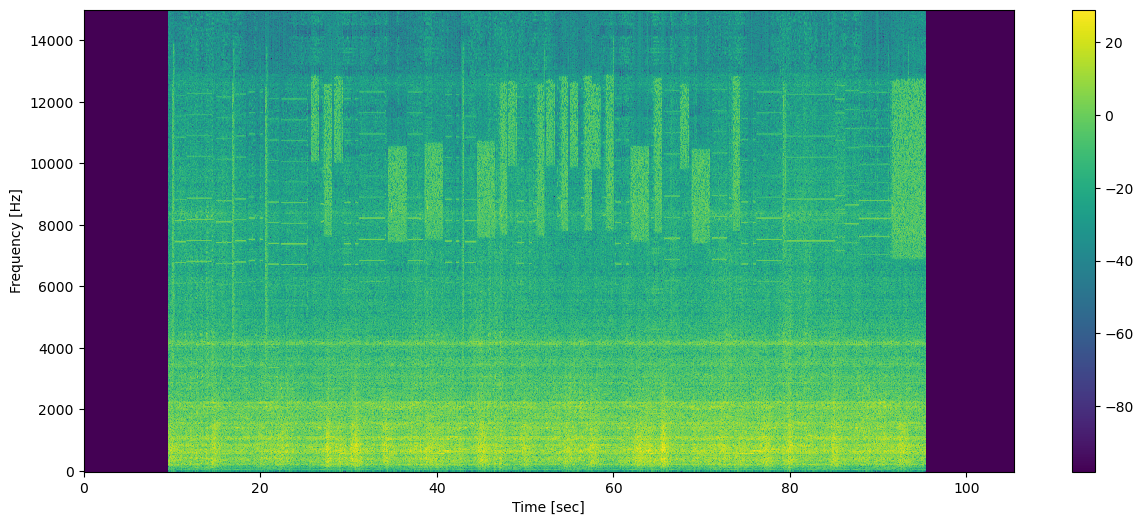

In [6]:
## Blank first 9.5 s and last 9.9 s, they shouldn't contain any signal
recording_crop[:, 0:int(9.5/FFT_sample_T)] = np.min(recording_crop)
recording_crop[:, -int(9.9/FFT_sample_T):] = np.min(recording_crop)

# Plot the blanked spectrogram
plt.figure(figsize=(15,6))
plt.pcolormesh(np.linspace(t_min, t_max, t_bins)[t_0:t_1], np.linspace(f_min, f_max, f_bins)[f_0:f_1], recording_crop)
plt.colorbar()
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

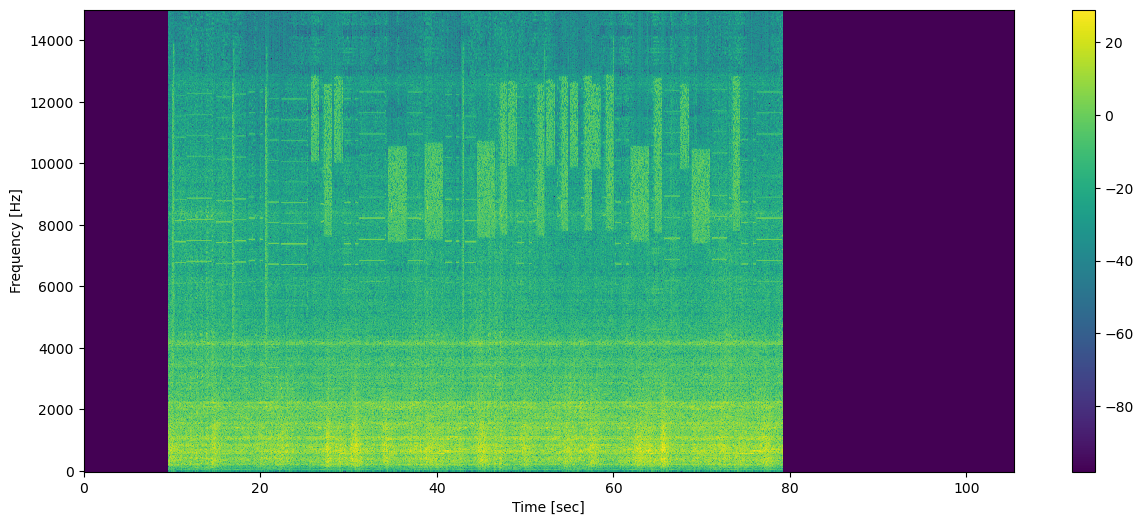

In [7]:
## Detect EOL signal
# Time corrections
t_start_corr = 16.18-3.90 # Correction to signal start time (s)
t_end_corr = 0.1 # Correction to signal end time (s)

# Signal detection
signal = np.genfromtxt('signal_samples/EOL_avg_48k-2000-75-Taylor.csv', delimiter=',').astype(np.float32) # Load signal
correlation_opencv = cv2.matchTemplate(recording_crop, signal, cv2.TM_CCOEFF_NORMED) # Signal correlation search based on OpenCV match template
local_maxima = peak_local_max(correlation_opencv, min_distance=10, threshold_abs=0.52) # Find local maxima locations
detected_times, detected_freqs = meas_time_freq(t_min, t_max, t_bins, local_maxima) # Convert the local maxima indices to time and frequency values
correl_values = correlation_opencv[local_maxima[:, 0], local_maxima[:, 1]] # Extract correlation values
signals_detected = signals2list("X", signals_detected, detected_times-t_start_corr, detected_freqs, correl_values) # Add to list of detected signals

# Blank spectrogram
recording_crop_blank_EOL = blank_spectrogram(recording_crop.copy(), local_maxima, t_start_corr, t_end_corr, signal, t_bins, FFT_sample_T)

# Plot the blanked spectrogram
plt.figure(figsize=(15,6))
plt.pcolormesh(np.linspace(t_min, t_max, t_bins)[t_0:t_1], np.linspace(f_min, f_max, f_bins)[f_0:f_1], recording_crop_blank_EOL)
plt.colorbar()
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

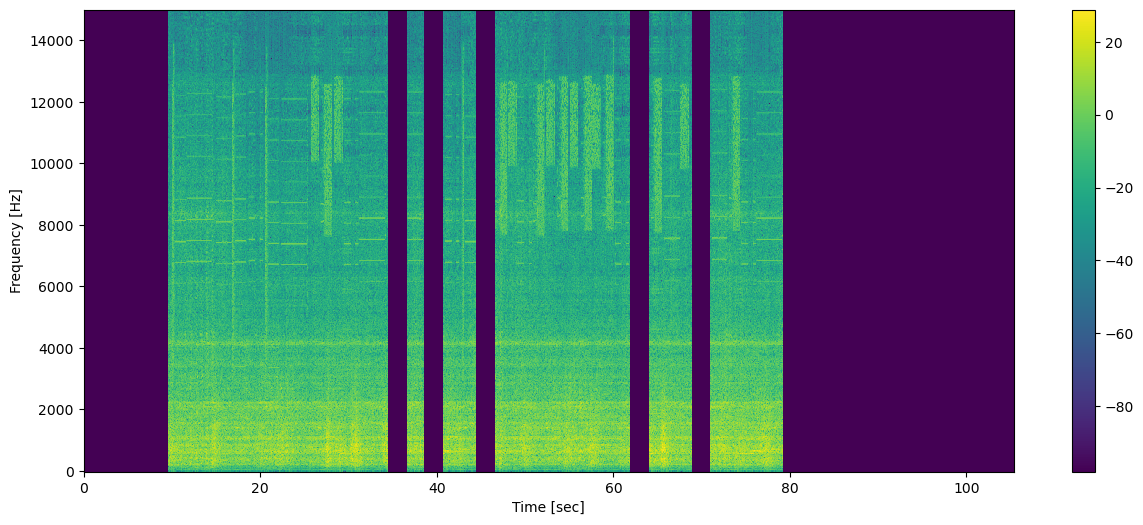

In [8]:
## Detect G signal
# Time corrections
t_start_corr = 0 # Correction to signal start time (s)
t_end_corr = 0 # Correction to signal end time (s)

# Signal detection
signal = np.genfromtxt('signal_samples/G_avg_48k-2000-75-Taylor.csv', delimiter=',').astype(np.float32) # Load signal
correlation_opencv = cv2.matchTemplate(recording_crop_blank_EOL, signal, cv2.TM_CCOEFF_NORMED) # Signal correlation search based on OpenCV match template
local_maxima = peak_local_max(correlation_opencv, min_distance=10, threshold_abs=0.36) # Find local maxima locations
detected_times, detected_freqs = meas_time_freq(t_min, t_max, t_bins, local_maxima) # Convert the local maxima indices to time and frequency values
correl_values = correlation_opencv[local_maxima[:, 0], local_maxima[:, 1]] # Extract correlation values
signals_detected = signals2list("G", signals_detected, detected_times-t_start_corr, detected_freqs, correl_values) # Add to list of detected signals

# Blank spectrogram
recording_crop_blank_G = blank_spectrogram(recording_crop_blank_EOL.copy(), local_maxima, t_start_corr, t_end_corr, signal, t_bins, FFT_sample_T)

# Plot the blanked spectrogram
plt.figure(figsize=(15,6))
plt.pcolormesh(np.linspace(t_min, t_max, t_bins)[t_0:t_1], np.linspace(f_min, f_max, f_bins)[f_0:f_1], recording_crop_blank_G)
plt.colorbar()
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

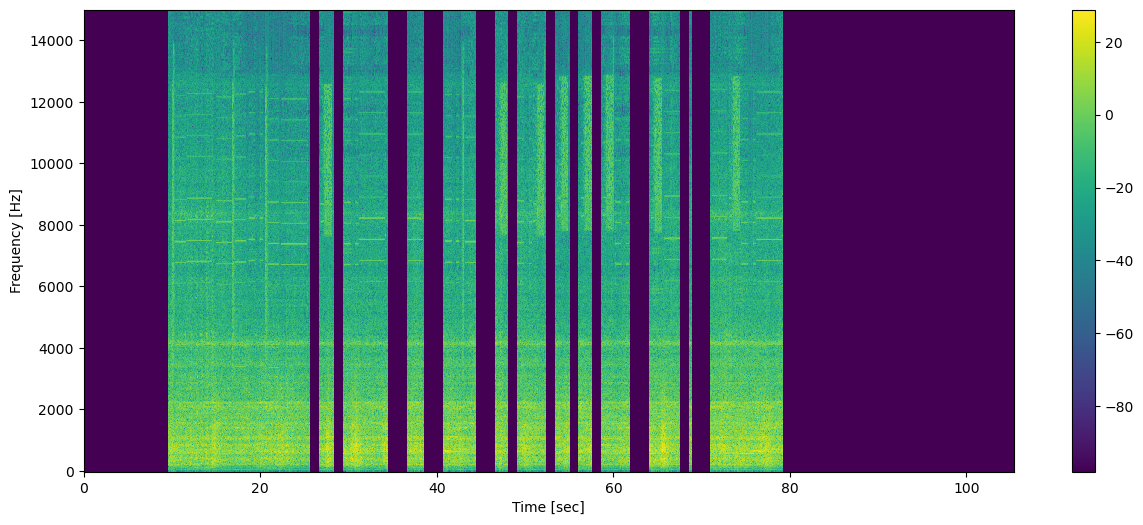

In [9]:
## Detect F signal
# Time corrections
t_start_corr = 0 # Correction to signal start time (s)
t_end_corr = 0 # Correction to signal end time (s)

# Signal detection
signal = np.genfromtxt('signal_samples/F_avg_48k-2000-75-Taylor.csv', delimiter=',').astype(np.float32) # Load signal
correlation_opencv = cv2.matchTemplate(recording_crop_blank_G, signal, cv2.TM_CCOEFF_NORMED) # Signal correlation search based on OpenCV match template
local_maxima = peak_local_max(correlation_opencv, min_distance=10, threshold_abs=0.53) # Find local maxima locations
detected_times, detected_freqs = meas_time_freq(t_min, t_max, t_bins, local_maxima) # Convert the local maxima indices to time and frequency values
correl_values = correlation_opencv[local_maxima[:, 0], local_maxima[:, 1]] # Extract correlation values
signals_detected = signals2list("F", signals_detected, detected_times-t_start_corr, detected_freqs, correl_values) # Add to list of detected signals

# Blank spectrogram
recording_crop_blank_F = blank_spectrogram(recording_crop_blank_G.copy(), local_maxima, t_start_corr, t_end_corr, signal, t_bins, FFT_sample_T)

# Plot the blanked spectrogram
plt.figure(figsize=(15,6))
plt.pcolormesh(np.linspace(t_min, t_max, t_bins)[t_0:t_1], np.linspace(f_min, f_max, f_bins)[f_0:f_1], recording_crop_blank_F)
plt.colorbar()
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

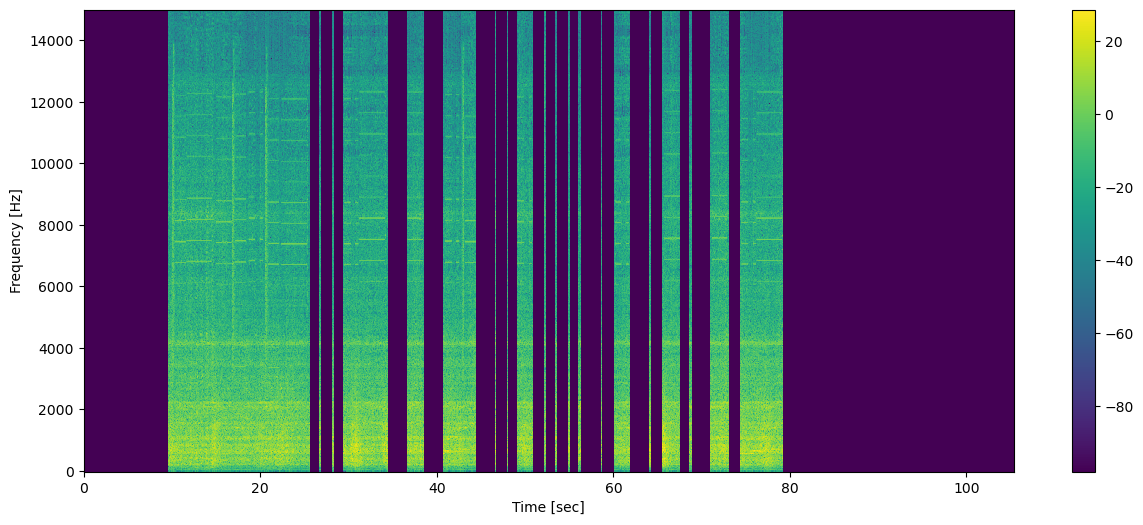

In [10]:
## Detect E signal
# Time corrections
t_start_corr = 1.27-0.89 # Correction to signal start time (s)
t_end_corr = 0 # Correction to signal end time (s)

# Signal detection
signal = np.genfromtxt('signal_samples/E_avg_48k-2000-75-Taylor.csv', delimiter=',').astype(np.float32) # Load signal
correlation_opencv = cv2.matchTemplate(recording_crop_blank_F, signal, cv2.TM_CCOEFF_NORMED) # Signal correlation search based on OpenCV match template
local_maxima = peak_local_max(correlation_opencv, min_distance=10, threshold_abs=0.40) # Find local maxima locations
detected_times, detected_freqs = meas_time_freq(t_min, t_max, t_bins, local_maxima) # Convert the local maxima indices to time and frequency values
correl_values = correlation_opencv[local_maxima[:, 0], local_maxima[:, 1]] # Extract correlation values
signals_detected = signals2list("E", signals_detected, detected_times-t_start_corr, detected_freqs, correl_values) # Add to list of detected signals

# Blank spectrogram
recording_crop_blank_E = blank_spectrogram(recording_crop_blank_F.copy(), local_maxima, t_start_corr, t_end_corr, signal, t_bins, FFT_sample_T)

# Plot the blanked spectrogram
plt.figure(figsize=(15,6))
plt.pcolormesh(np.linspace(t_min, t_max, t_bins)[t_0:t_1], np.linspace(f_min, f_max, f_bins)[f_0:f_1], recording_crop_blank_E)
plt.colorbar()
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

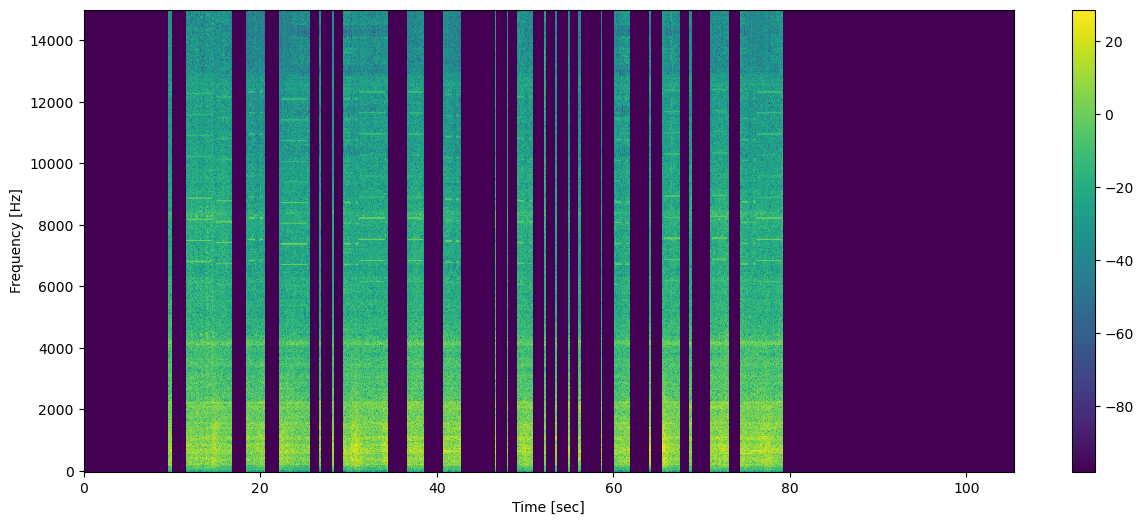

In [11]:
## Detect D signal
# Time corrections
t_start_corr = 1.27-0.89 # Correction to signal start time (s)
t_end_corr = 0 # Correction to signal end time (s)

# Signal detection
signal = np.genfromtxt('signal_samples/D_avg_48k-2000-75-Taylor.csv', delimiter=',').astype(np.float32) # Load signal
correlation_opencv = cv2.matchTemplate(recording_crop_blank_E, signal, cv2.TM_CCOEFF_NORMED) # Signal correlation search based on OpenCV match template
local_maxima = peak_local_max(correlation_opencv, min_distance=10, threshold_abs=0.48) # Find local maxima locations
detected_times, detected_freqs = meas_time_freq(t_min, t_max, t_bins, local_maxima) # Convert the local maxima indices to time and frequency values
correl_values = correlation_opencv[local_maxima[:, 0], local_maxima[:, 1]] # Extract correlation values
signals_detected = signals2list("D", signals_detected, detected_times-t_start_corr, detected_freqs, correl_values) # Add to list of detected signals

# Blank spectrogram
t_start_corr = 0 # Correction to signal start time (s)
t_end_corr = 1.61-0.31 # Correction to signal end time (s)
recording_crop_blank_D = blank_spectrogram(recording_crop_blank_E.copy(), local_maxima, t_start_corr, t_end_corr, signal, t_bins, FFT_sample_T)

# Plot the blanked spectrogram
plt.figure(figsize=(15,6))
plt.pcolormesh(np.linspace(t_min, t_max, t_bins)[t_0:t_1], np.linspace(f_min, f_max, f_bins)[f_0:f_1], recording_crop_blank_D)
plt.colorbar()
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

In [12]:
## Measure background noise level
noise = spec_bandpass(Sx2_dB, f_max, f_bins, 6300, 6700) # Extract noise band
noise_mean = np.mean(noise) # Noise mean level
noise_std = np.std(noise) # Noise standard deviation

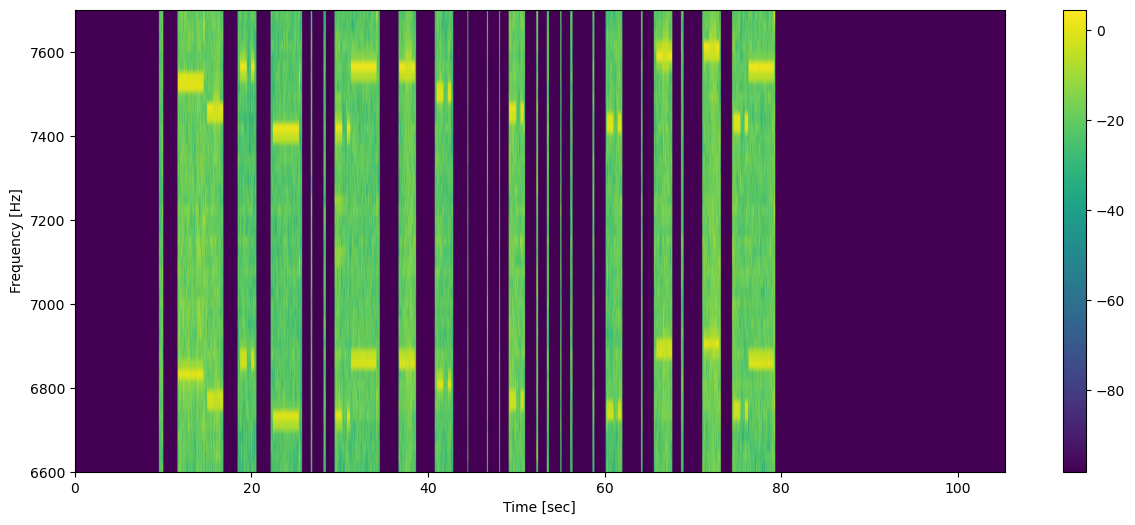

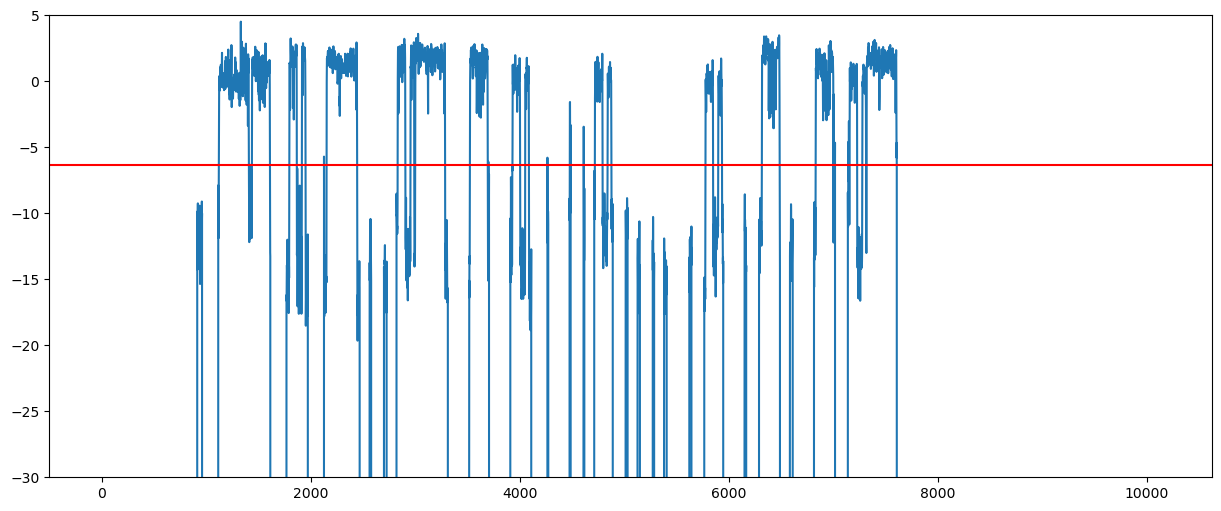

In [13]:
## Measure signal level in strong "tone" band
f_low = 6600
f_high = 7700
sig_bandpass = spec_bandpass(recording_crop_blank_D, f_max, f_bins, f_low, f_high)
sig_level = np.max(sig_bandpass, axis=0)

std_num = 2.25 # Number of standard deviations to use for thresholding

# Plot 'cropped' spectrogram  (in dB)
plt.figure(figsize=(15,6))
plt.imshow(sig_bandpass, origin='lower', aspect='auto', extent=[t_min, t_max, f_low, f_high])
plt.colorbar()
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

plt.figure(figsize=(15,6))
plt.plot(sig_level)
plt.axhline(y = noise_mean + noise_std*std_num, color = 'r', linestyle = '-')
plt.ylim(-30, 5)
plt.show()

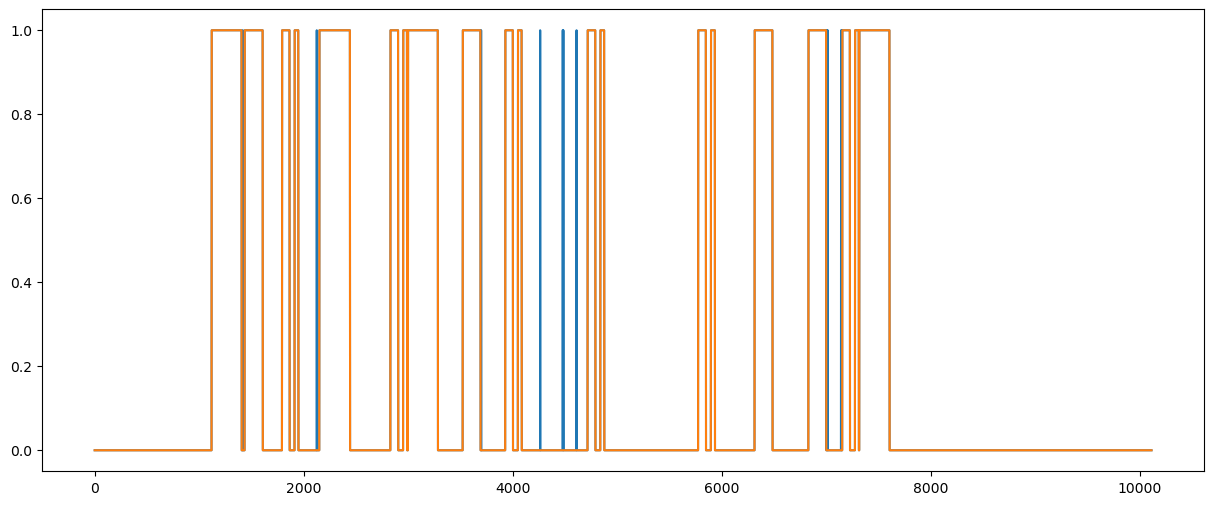

In [14]:
## Create "detection" array
threshold = noise_mean + noise_std*std_num # Threshold level to detect a signal
above_threshold = (sig_level > threshold).astype(int) # Array of detections (1) and non-detections (0)
min_ones = int(0.26/FFT_sample_T) # 0.26 seconds, = 0.67 * 0.38 s (the shortest portion of signal C)
sig_detected = remove_short_detections(above_threshold, min_ones)

plt.figure(figsize=(15,6))
plt.plot(above_threshold)
plt.plot(sig_detected)
plt.show()

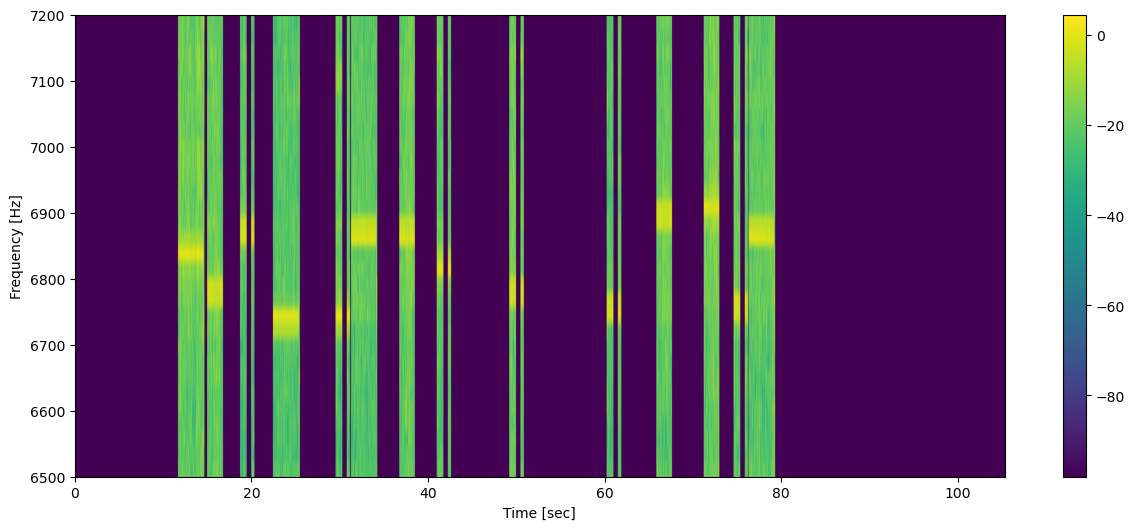

In [15]:
## Blanking of noise sections based on previous detections, then bandpass to low frequency strong tone.
# Cropping based on sig_detected, applied to the original cropped spectrogram
recording_crop_blank_tones = recording_crop.copy()
recording_crop_blank_tones[:, np.where(sig_detected == 0)[0]] = np.min(recording_crop)

# First bandpass filter (wide)
f_low_1 = 6500
f_high_1 = 7200
recording_crop_blank_tones_bp1 = spec_bandpass(recording_crop_blank_tones, f_max, f_bins, f_low_1, f_high_1)

# Plot 'cropped' spectrogram  (in dB)
plt.figure(figsize=(15,6))
plt.imshow(recording_crop_blank_tones_bp1, origin='lower', aspect='auto', extent=[t_min, t_max, f_low_1, f_high_1])
plt.colorbar()
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

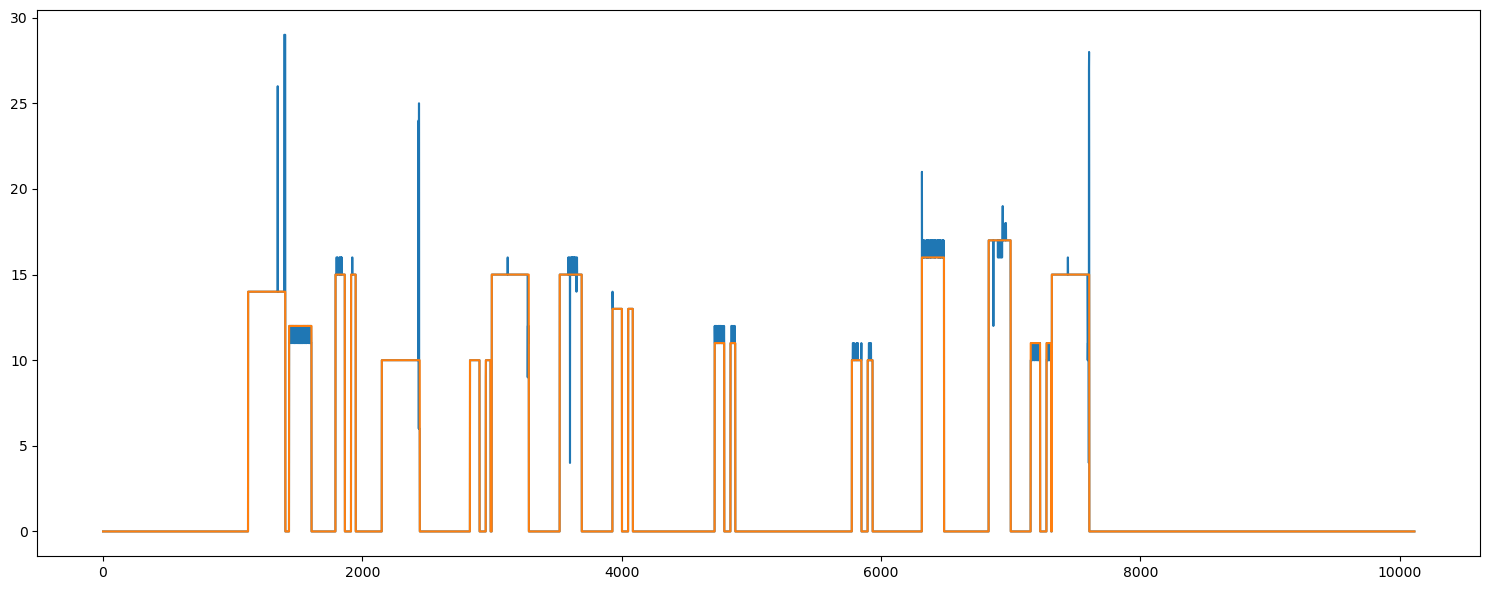

In [16]:
## Find local maxima for each tone (frequency sample), 1st pass
# Local maxima, this is often noisy
tones_local_max = np.argmax(recording_crop_blank_tones_bp1, axis=0)

# Find indices at the end tone segments
det_idx = np.where(sig_detected == 1)[0] # Find the indices where a tone is s detected
tone_segm_boundaries = np.where(np.diff(det_idx) > 1)[0] + 1 # Find the boundaries where the difference is greater than 1
tone_segm_boundaries = np.concatenate(([0], tone_segm_boundaries, [len(det_idx)])) # Add the first and last index to define the tone segments

# Calculate the median of tones_local_max for each tone segment
medians = []
for i in range(len(tone_segm_boundaries) - 1):
    segment = det_idx[tone_segm_boundaries[i]:tone_segm_boundaries[i+1]]
    medians.append(np.median(tones_local_max[segment]))

# Initialize an array for tones_local_max_med, add the corresponding median for each segment (this works as a filter)
tones_freq_med = np.copy(tones_local_max)
segment_start = 0
for i in range(len(tone_segm_boundaries) - 1):
    segment = det_idx[tone_segm_boundaries[i]:tone_segm_boundaries[i+1]]
    median_value = medians[i]
    tones_freq_med[segment] = median_value

# Plot both original and modified (median) tones
plt.figure(figsize=(15,6))
plt.plot(tones_local_max)
plt.plot(tones_freq_med)
plt.tight_layout()
plt.show()

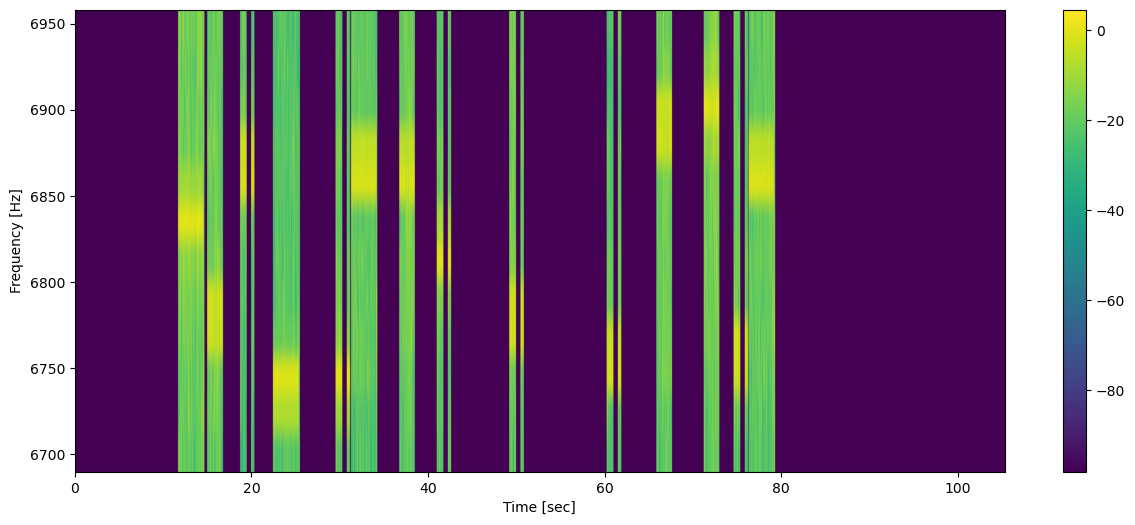

In [17]:
## Determine min/max tone frequencies, then run second bandpass (narrow)
margin = 50 # Frequency margin below and above tones
f_low_2 = np.min(tones_freq_med[tones_freq_med != 0])*fs/win_size + f_low_1 - margin
f_high_2 = np.max(tones_freq_med)*fs/win_size + f_low_1 + margin
recording_crop_blank_tones_bp2 = spec_bandpass(recording_crop_blank_tones, f_max, f_bins, f_low_2, f_high_2)

# Plot 'cropped' spectrogram  (in dB)
plt.figure(figsize=(15,6))
plt.imshow(recording_crop_blank_tones_bp2, origin='lower', aspect='auto', extent=[t_min, t_max, f_low_2, f_high_2])
plt.colorbar()
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

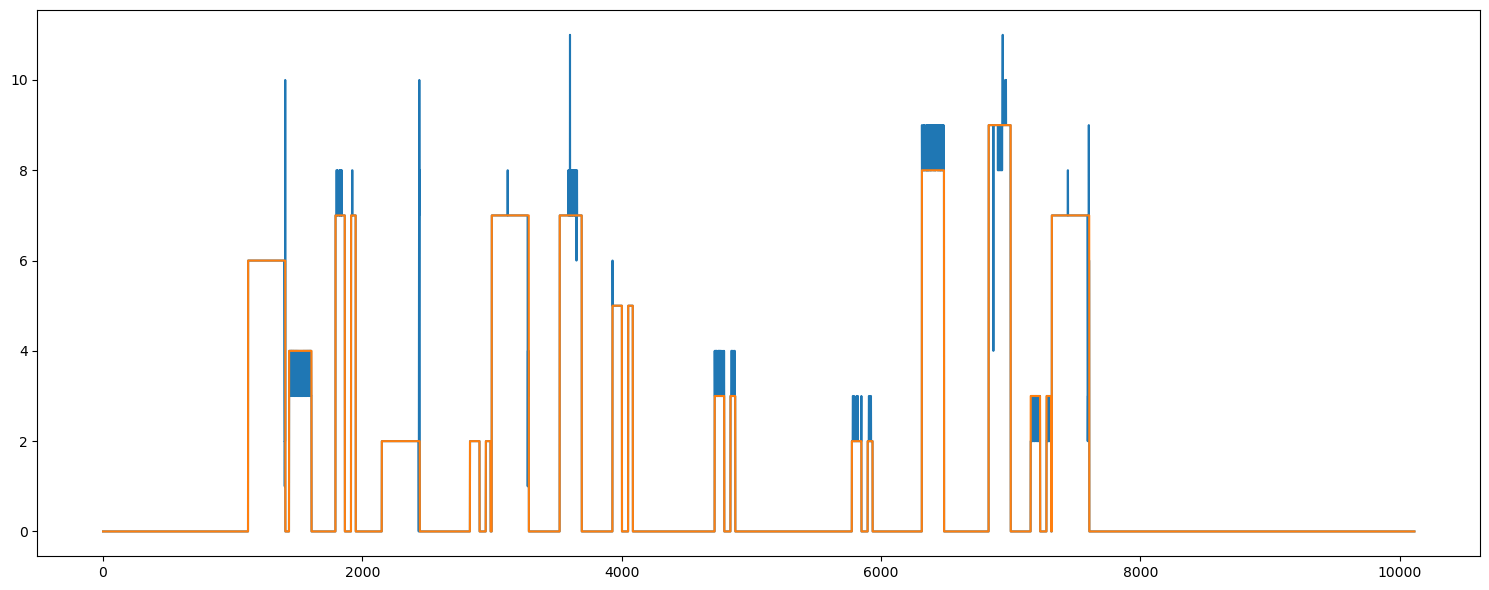

In [18]:
## Find local maxima for each tone (frequency sample), 2nd pass
# Local maxima, this is often noisy
tones_local_max = np.argmax(recording_crop_blank_tones_bp2, axis=0)

# Find indices nd tone segments
det_idx = np.where(sig_detected == 1)[0] # Find the indices where a tone is s detected
tone_segm_boundaries = np.where(np.diff(det_idx) > 1)[0] + 1 # Find the boundaries where the difference is greater than 1
tone_segm_boundaries = np.concatenate(([0], tone_segm_boundaries, [len(det_idx)])) # Add the first and last index to define the tone segments

# Calculate the median of tones_local_max for each tone segment
medians = []
for i in range(len(tone_segm_boundaries) - 1):
    segment = det_idx[tone_segm_boundaries[i]:tone_segm_boundaries[i+1]]
    medians.append(np.median(tones_local_max[segment]))

# Initialize an array for tones_local_max_med, add the corresponding median for each segment (this works as a filter)
tones_freq_med = np.copy(tones_local_max)
segment_start = 0
for i in range(len(tone_segm_boundaries) - 1):
    segment = det_idx[tone_segm_boundaries[i]:tone_segm_boundaries[i+1]]
    median_value = medians[i]
    tones_freq_med[segment] = median_value

# Plot both original and modified (median) tones
plt.figure(figsize=(15,6))
plt.plot(tones_local_max)
plt.plot(tones_freq_med)
plt.tight_layout()
plt.show()

In [19]:
## Detect tones
# Find tone signals (as sequences of values above 0)
tone_signals = find_tone_signals(sig_detected, tones_freq_med)

# Print the result with start_idx, end_idx, and median value
for row in tone_signals:
    print(str(row) + " " + str(row[1]-row[0]))
    

(1119, 1405, 6) 286
(1435, 1607, 4) 172
(1793, 1864, 7) 71
(1913, 1948, 7) 35
(2150, 2442, 2) 292
(2830, 2903, 2) 73
(2952, 2988, 2) 36
(2998, 3283, 7) 285
(3522, 3691, 7) 169
(3929, 4001, 5) 72
(4050, 4085, 5) 35
(4717, 4790, 3) 73
(4839, 4875, 3) 36
(5775, 5848, 2) 73
(5897, 5934, 2) 37
(6315, 6485, 8) 170
(6830, 6999, 9) 169
(7154, 7226, 3) 72
(7276, 7311, 3) 35
(7317, 7605, 7) 288


In [20]:
# Detect which tones occur
try:
    tones_list = translate_tones(tone_signals, FFT_sample_T)
except ValueError as e:
    print(f"Error: {e}")

# Convert to time and frequency values
tone_type = np.array(tones_list)[:, 3]
tone_times = np.array([row[0] for row in tones_list])
tone_freqs = np.array([row[4] for row in tones_list])
detected_times = np.linspace(t_min, t_max, t_bins)[tone_times] # Time values from indices
detected_freqs = np.linspace(f_min, f_max, f_bins)[tone_freqs] + f_low_2  # Frequency values from indices, corrected for previous bandpass

# Calculate length metric
length_metric = np.zeros(len(tones_list))
length_samples = np.array([row[2] for row in tones_list]) # Length of tones (in # samples), it shouldn't differ much from 'standard' values
for t in range(len(length_samples)):
    if tone_type[t] == "A":
        A_sample_length = int(sig_length('A')/FFT_sample_T)
        length_metric[t] = (1 - ((length_samples[t] - A_sample_length) / A_sample_length))  # Tone A length metric
    if tone_type[t] == "B":
        B_sample_length = int(sig_length('B')/FFT_sample_T)
        length_metric[t] = (1 - ((length_samples[t] - B_sample_length) / B_sample_length))  # Tone B length metric
    if tone_type[t] == "C":
        C_sample_length = int(sig_length('C')/FFT_sample_T)
        length_metric[t] = (1 - ((length_samples[t] - C_sample_length) / C_sample_length))  # Tone C length metric

# Add to list of detected signals
for i in range(len(detected_times)):
    signals_detected.append([
        tone_type[i], # Signal type
        round(detected_times[i], 2), # Time rounded to 2 decimal places
        int(detected_freqs[i]), # Frequency as an integer
        round(length_metric[i], 2) # Length metric as an integer
    ])

In [21]:
## Final signal sorting and checks
# Sort list based on time
signals_detected = sorted(signals_detected[:], key=lambda x: x[1])

# Sequence validation
def validate_list(signals_detected):
    # Check 1: EOL occurs only once
    x_count = sum(1 for item in signals_detected if item[0] == 'X')
    if x_count != 1:
        print("Error: EOL signal appears more than once!")
        return True
    # Check 2: EOL occurs at the end
    if  signals_detected[-1][0] != 'X':
        print("Error: EOL signal found before the end of the sequence!")
        return True
    # Check 3: No consecutive signals of the same type
    for i in range(1, len(signals_detected)):
        if signals_detected[i][0] == signals_detected[i - 1][0]:
            print(f"Error: Consecutive signal '{signals_detected[i][0]}' found at positions {i-1} and {i}.")
            return True
    # Check 4: No excessive gap between signals, set at 90% of 0.98 s (the shortest signal)
    for i in range(1, len(signals_detected)):
        t_gap = signals_detected[i][1] - signals_detected[i-1][1] - sig_length(signals_detected[i-1][0])
        if t_gap > 0.98*0.9:
            t_gap_start = signals_detected[i-1][1] + sig_length(signals_detected[i-1][0])
            print(f"Error: Likely undetected signal at {i} {t_gap_start} s for {t_gap} s")
            return True            
    return True

if validate_list(signals_detected):
    for row in signals_detected:
        print(row)

['D', 9.59, 7867, 0.79]
['A', 11.64, 6822, 1.01]
['B', 14.93, 6774, 0.98]
['D', 16.4, 7891, 0.85]
['C', 18.66, 6846, 1.01]
['D', 20.14, 7771, 0.9]
['A', 22.38, 6726, 0.99]
['F', 25.68, 10054, 0.68]
['E', 26.83, 7531, 0.6]
['F', 28.37, 10006, 0.79]
['C', 29.47, 6726, 0.99]
['A', 31.22, 6846, 1.01]
['G', 34.48, 7411, 0.9]
['B', 36.68, 6846, 1.0]
['G', 38.58, 7531, 0.62]
['C', 40.92, 6798, 1.0]
['D', 42.41, 7867, 0.8]
['G', 44.49, 7579, 0.55]
['E', 46.71, 7603, 0.69]
['F', 48.08, 9861, 0.79]
['C', 49.12, 6750, 0.99]
['E', 50.91, 7555, 0.61]
['F', 52.4, 9909, 0.89]
['E', 53.62, 7771, 0.9]
['F', 55.04, 9837, 0.93]
['E', 56.29, 7771, 0.86]
['F', 57.56, 9789, 0.88]
['E', 58.76, 7795, 0.84]
['C', 60.15, 6726, 0.98]
['G', 61.93, 7435, 0.73]
['E', 64.21, 7699, 0.82]
['B', 65.77, 6870, 0.99]
['F', 67.58, 9765, 0.77]
['G', 68.86, 7339, 0.77]
['B', 71.14, 6894, 1.0]
['E', 73.07, 7771, 0.85]
['C', 74.51, 6750, 0.99]
['A', 76.21, 6846, 1.0]
['X', 79.22, 6882, 0.94]
